# Standard Scalling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv('/content/sample_data/diabetes.csv')
df.head(6)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [86]:
df=df.replace(0,np.nan) # replace 0 by nan so we can count

In [87]:
df.isnull().sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


### Handling Null values

observe the missing values count. **Skin thickness**  and  **insulin**  has the highest missing value , whether **glucose** , **blood pressure**,**BMI** has less. So , we have to make the decision what types filling operations we should do.


**Pregnancy Handling**

In [62]:
df['Pregnancies']=df['Pregnancies'].replace(0,np.nan)

**Blood Pressure Handling**

In [30]:
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].median())

In [31]:
df['BloodPressure'].isnull().sum()

np.int64(0)

**BMI Handling**

In [35]:
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

In [36]:
df['BMI'].isnull().sum()

np.int64(0)

**Glucose Handling**

In [39]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())

In [40]:
df['Glucose'].isnull().sum()

np.int64(0)

**skin thickness and insuline handling**

In [41]:
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin']=df['Insulin'].fillna(df['Insulin'].median())

In [63]:
df.isnull().sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


## Check missing value visually

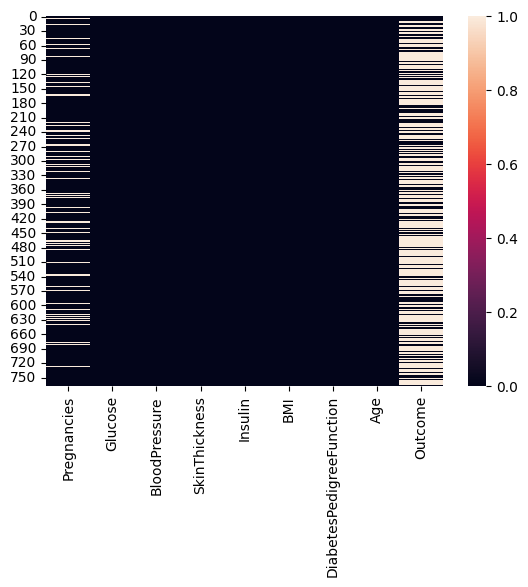

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull())

plt.show()

## splitting dataset in train and test

Charges is the target column so we seperate charges from others column

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train,y_test = train_test_split(df.drop('Outcome',axis=1),df['Outcome'],
test_size=0.3,random_state=42)


X_train.shape,X_test.shape

((537, 8), (231, 8))

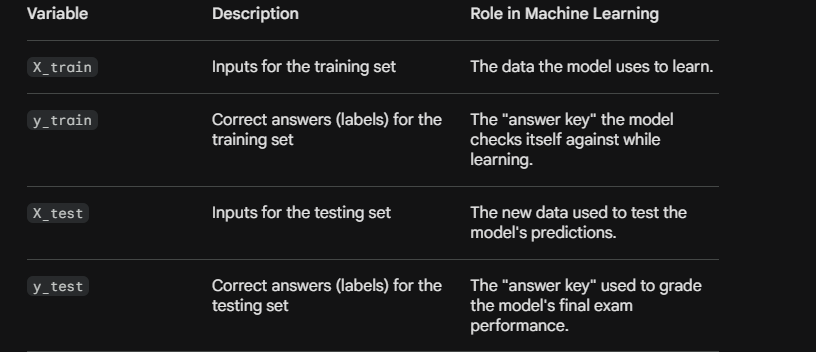

## StdScaler

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler to the train set
scaler.fit(X_train)

#transform train and test set

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
X_train #original col & val

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
334,1.0,95.0,60.0,18.0,58.0,23.9,0.260,22
139,5.0,105.0,72.0,29.0,325.0,36.9,0.159,28
485,NaN,135.0,68.0,42.0,250.0,42.3,0.365,24
547,4.0,131.0,68.0,21.0,166.0,33.1,0.160,28
18,1.0,103.0,30.0,38.0,83.0,43.3,0.183,33
...,...,...,...,...,...,...,...,...
71,5.0,139.0,64.0,35.0,140.0,28.6,0.411,26
106,1.0,96.0,122.0,29.0,125.0,22.4,0.207,27
270,10.0,101.0,86.0,37.0,125.0,45.6,1.136,38
435,NaN,141.0,72.0,29.0,125.0,42.4,0.205,29


In [72]:
X_train_scaled  #scaled npArray

array([[-1.07189177, -0.89454593, -1.00322115, ..., -1.20382556,
        -0.61421636, -0.94861028],
       [ 0.21159422, -0.56247683, -0.01909007, ...,  0.66449801,
        -0.90973787, -0.43466673],
       [        nan,  0.43373048, -0.34713376, ...,  1.44057087,
        -0.30699103, -0.77729576],
       ...,
       [ 1.8159517 , -0.69530447,  1.12906286, ...,  1.91483763,
         1.94892066,  0.42190587],
       [        nan,  0.63297195, -0.01909007, ...,  1.45494259,
        -0.77514391, -0.34900947],
       [        nan,  0.10166138,  1.9491721 , ..., -1.40502964,
        -0.60836445, -1.03426754]])

 ***It returns numpy array , So we have to  convert the numpy array into dataFrame.***

In [73]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

## View The Scaled Value in DataFrame

In [74]:
X_train_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.071892,-0.894546,-1.003221,-1.269545,-0.956993,-1.203826,-0.614216,-0.948610
1,0.211594,-0.562477,-0.019090,0.029693,2.136797,0.664498,-0.909738,-0.434667
2,NaN,0.433730,-0.347134,1.565156,1.267755,1.440571,-0.306991,-0.777296
3,-0.109277,0.300903,-0.347134,-0.915207,0.294428,0.118373,-0.906812,-0.434667
4,-1.071892,-0.628891,-3.463549,1.092706,-0.667312,1.584288,-0.839515,-0.006380
...,...,...,...,...,...,...,...,...
532,0.211594,0.566558,-0.675177,0.738368,-0.006840,-0.528355,-0.172397,-0.605981
533,-1.071892,-0.861339,4.081456,0.029693,-0.180649,-1.419401,-0.769292,-0.520324
534,1.815952,-0.695304,1.129063,0.974593,-0.180649,1.914838,1.948921,0.421906
535,NaN,0.632972,-0.019090,0.029693,-0.180649,1.454943,-0.775144,-0.349009


## Check IS it Scaled?

In [75]:
X_train_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,4.610000e+02,5.370000e+02,5.370000e+02,5.370000e+02,5.370000e+02,5.370000e+02,5.370000e+02,5.370000e+02
mean,-4.431259e-17,2.083994e-16,-4.167988e-16,5.292683e-17,-1.124695e-16,6.946647e-17,-9.923781e-17,-2.646342e-16
std,1.001086e+00,1.000932e+00,1.000932e+00,1.000932e+00,1.000932e+00,1.000932e+00,1.000932e+00,1.000932e+00
min,-1.071892e+00,-2.588098e+00,-3.955614e+00,-2.450670e+00,-1.466831e+00,-2.023014e+00,-1.146740e+00,-1.034268e+00
25%,-7.510203e-01,-7.285114e-01,-6.751775e-01,-5.608695e-01,-2.385847e-01,-7.439305e-01,-6.698095e-01,-7.772958e-01
50%,-1.092773e-01,-1.639939e-01,-1.909007e-02,2.969309e-02,-1.806486e-01,-3.971626e-02,-2.806574e-01,-3.490095e-01
75%,5.324657e-01,5.665581e-01,6.369973e-01,3.840306e-01,-1.342997e-01,6.070111e-01,4.157200e-01,6.788776e-01
max,4.062052e+00,2.558973e+00,4.081456e+00,4.045519e+00,8.173744e+00,5.004757e+00,5.705848e+00,4.105168e+00


Here Standard Deviation is 1 and mean is 0,
Give the Value gpt will exaplian , they are float type value

## Visualization

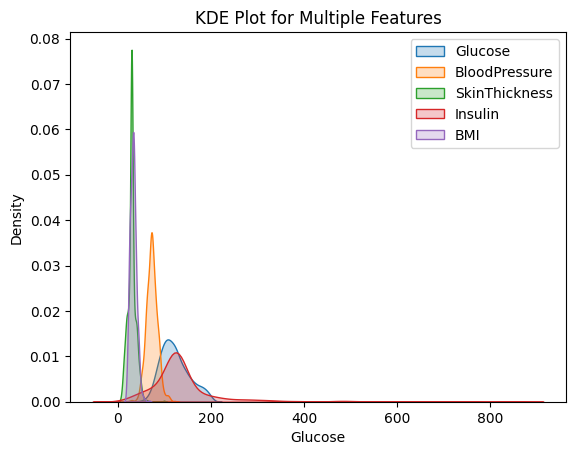

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Glucose', 'BloodPressure',
        'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    sns.kdeplot(data=df[col], fill=True, label=col)

plt.title("KDE Plot for Multiple Features")
plt.legend()
plt.show()

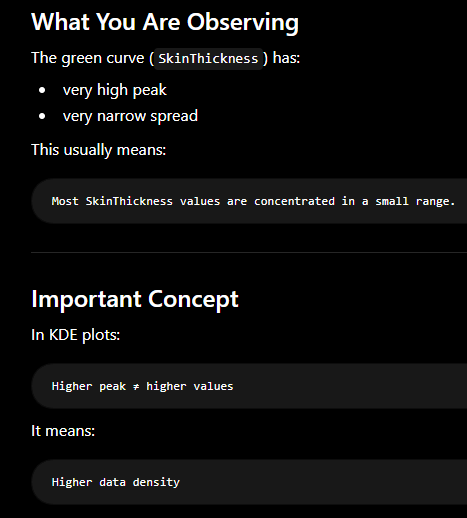

# MinMax Scalling

**Normalization in scaling (often called Min-Max Scaling) is a data preprocessing technique that transforms numerical features to a standard range, typically 0 to 1. It eliminates the dominance of large-magnitude features by rescaling, ensuring all features contribute equally to machine learning models, particularly distance-based algorithms**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/sample_data/Wine dataset.csv')
df.head(7)

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290


In [3]:
df.isnull().sum()

,0
class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


**There are many columns but we will work with some specific columns , So we extract some specific columns as per easy working.**

In [9]:
df=pd.read_csv('/content/sample_data/Wine dataset.csv',usecols=[0,1,2,5])
df.columns=['class','Alcohol','Malic acid','Magnesium']

In [10]:
df

,class,Alcohol,Malic acid,Magnesium
0,1,14.23,1.71,127
1,1,13.20,1.78,100
2,1,13.16,2.36,101
3,1,14.37,1.95,113
4,1,13.24,2.59,118
...,...,...,...,...
173,3,13.71,5.65,95
174,3,13.40,3.91,102
175,3,13.27,4.28,120
176,3,13.17,2.59,120


## Splitting dataset

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop('class',axis=1),
                                                 df['class'],
                                                 test_size=0.3,
                                                 random_state =42
                                                 )

X_train.shape,X_test.shape


((124, 3), (54, 3))

## Apply Scalling

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit the scaler to train set, it will learn the parameter
scaler.fit(X_train)

#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## View scaled npArray

In [13]:
#View scaled numpy array

X_train_scaled

array([[0.64736842, 0.54989817, 0.19565217],
       [0.38947368, 0.17107943, 0.16304348],
       [0.34210526, 0.0203666 , 0.7173913 ],
       [0.59210526, 0.15274949, 0.43478261],
       [0.33157895, 0.39511202, 0.19565217],
       [0.70526316, 0.19755601, 0.33695652],
       [0.75      , 0.84521385, 0.10869565],
       [0.33157895, 0.10590631, 0.16304348],
       [0.31052632, 0.0610998 , 0.88043478],
       [0.47105263, 0.50509165, 0.19565217],
       [0.81315789, 0.12016293, 0.27173913],
       [0.88421053, 0.19959267, 0.2826087 ],
       [0.59736842, 0.16904277, 0.26086957],
       [0.32105263, 0.6089613 , 0.45652174],
       [0.58157895, 0.34623218, 0.52173913],
       [0.69736842, 0.19144603, 0.36956522],
       [0.37894737, 0.12830957, 1.        ],
       [0.30789474, 0.43584521, 0.2826087 ],
       [0.16578947, 0.20162933, 0.29347826],
       [0.80789474, 0.2586558 , 0.38043478],
       [0.48421053, 0.75763747, 0.17391304],
       [0.53157895, 1.        , 0.17391304],
       [0.

## conv npArr to DataFrame

In [16]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

## View Scaled DataFrame

In [17]:
X_train_scaled

,Alcohol,Malic acid,Magnesium
0,0.647368,0.549898,0.195652
1,0.389474,0.171079,0.163043
2,0.342105,0.020367,0.717391
3,0.592105,0.152749,0.434783
4,0.331579,0.395112,0.195652
...,...,...,...
119,0.744737,0.126273,0.173913
120,0.321053,0.171079,0.108696
121,0.881579,0.199593,0.347826
122,0.436842,0.130346,0.108696


## Graph After scalling

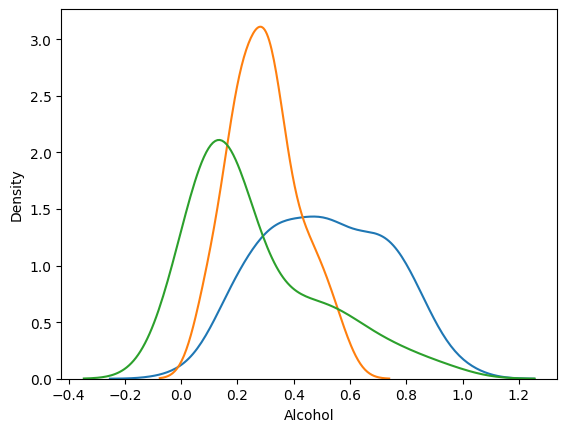

In [21]:
sns.kdeplot(X_train_scaled['Alcohol'])
sns.kdeplot(X_test_scaled['Magnesium'])
sns.kdeplot(X_test_scaled['Malic acid'])
plt.show()

**Here all 3 Features are scaled and came into the range of 0-1**

# Robust Scalling

In [22]:
df=pd.read_csv('/content/sample_data/creditcard.csv')
df.head(7)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize RobustScaler
scaler = RobustScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame just to inspect the beautifully scaled data
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print(X_train_scaled_df.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  0.800782 -0.161890  0.393704 -1.370053 -1.808112  2.803183  2.635836   
1 -0.789047 -0.289222  0.259084  0.456916 -0.347371  1.000061  1.785237   
2  0.032411 -1.218902  2.054770 -0.824367 -0.536990 -1.322811 -0.658558   
3  0.662755  0.768227  0.206341 -0.145797  1.246094 -0.037294 -0.256703   
4 -0.560492 -1.053154 -2.521049 -1.101911  0.383145 -0.802896  1.898174   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0  0.168447 -0.480880  0.846703  ...  0.400258  2.520335  0.038478 -0.498344   
1 -0.135230 -0.529166  0.747945  ... -1.799864  1.470161 -1.016901 -0.332213   
2 -0.757907  2.840078  0.419230  ...  1.401985 -0.421645 -0.453550  0.836657   
3  0.059196 -0.407590 -0.802379  ... -0.223495 -0.000363 -0.132863  0.240635   
4  4.093004 -0.093462 -1.421696  ...  7.237155  2.115308 -0.093323  7.598007   

        V24       V25       V26       V27       V28     Amount  
0  